# Building a Harness

Welcome to the third notebook of the Harness Engineering module. In notebook 01 you saw one question answered three ways and learned the module's one-line canon: **an agent is a model plus a harness**. In notebook 02 you took the harness apart into its pieces: models, context, tools and skills. Today you put those pieces together into a working system, and then you do the thing most tutorials skip: you **measure** it.

In plain words: the model is the engine, the harness is the rest of the car. In this notebook you build the steering (the loop), the brakes and seatbelts (guardrails and permissions), the route planning (workflow patterns), and the dashboard (evals and traces).

**What you will learn**

- How the agent loop works: gather context, take action, verify work, repeat, and the three ways a run stops.
- How hooks and permissions run checks *outside* the model, before a tool runs and after an answer comes back.
- The five workflow patterns from Anthropic's "Building effective agents" (19 Dec 2024), each run for real, and when to let the model drive instead.
- How to write an eval suite (a task, a grader, an outcome) and use it to compare three harness configurations.
- How to read a trace, count tokens and turn them into money.

**Sources used in this notebook** (the same texts sit in the agent's library, `harness/corpus/`): Anthropic, "Building effective agents" (19 Dec 2024); OpenAI, "A practical guide to building agents" (Apr 2025); Anthropic, "Demystifying evals for AI agents" (Jan 2026); OpenAI, "Harness engineering: leveraging Codex in an agent-first world" (11 Feb 2026); Marmelab, "The State of AI Harness Engineering 2026" (24 Sep 2026).

## How to run this notebook

- **Locally (Jupyter):** open this file in Jupyter and run the cells top to bottom.
- **Google Colab:** open the notebook from GitHub in [colab.research.google.com](https://colab.research.google.com) and run the cells top to bottom. The first cell downloads the small `harness` library (public files, no account, no key).

Running everything requires **no API key**. The course ships a `ScriptedModel`: a stand-in for a language model whose behaviour is a few lines of Python. It answers the same way every time, so you can change the harness and see exactly what changed, because the model never does. The *optional* last section shows how to plug in a real model (Claude or GPT) behind the same interface; it is skipped unless you flip a switch and paste a key.

Every printed number in this notebook comes from the code above it. Run the cells and the numbers appear; nothing is typed in by hand.

In [1]:
# Setup: the notebooks use a small teaching library called `harness` that lives next to them
# in the repository. In Google Colab the folder is not there, so we download it (public files,
# no key, no account). Locally and in CI it is already present.
import pathlib, sys, urllib.request

REPO = "https://raw.githubusercontent.com/maglionejm/fontys-tech-exercises/main/M5%20-%20Harness%20Engineering/"
FILES = [
    "harness/__init__.py",
    "harness/agent.py",
    "harness/context.py",
    "harness/corpus/agent-skills.md",
    "harness/corpus/context-engineering.md",
    "harness/corpus/evals-and-observability.md",
    "harness/corpus/harness-effect.md",
    "harness/corpus/model-context-protocol.md",
    "harness/corpus/multi-agent-systems.md",
    "harness/corpus/prompt-to-harness-timeline.md",
    "harness/corpus/tool-design.md",
    "harness/corpus/what-is-a-harness.md",
    "harness/corpus/workflow-patterns.md",
    "harness/demo_tools.py",
    "harness/evals.py",
    "harness/messages.py",
    "harness/models.py",
    "harness/multi.py",
    "harness/patterns.py",
    "harness/policies.py",
    "harness/providers.py",
    "harness/skills.py",
    "harness/skills/cite-sources/SKILL.md",
    "harness/skills/cite-sources/checklist.md",
    "harness/skills/safe-calculations/SKILL.md",
    "harness/skills/summarize-brief/SKILL.md",
    "harness/skills/summarize-brief/template.md",
    "harness/tools.py",
    "harness/trace.py",
]
if not pathlib.Path("harness/__init__.py").exists():
    for name in FILES:
        target = pathlib.Path(name); target.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(REPO + name.replace(" ", "%20"), target)
    print(f"Downloaded the harness library ({len(FILES)} files).")
sys.path.insert(0, ".")
import harness
print("harness", harness.__version__, "ready")

harness 0.1.0 ready


## 1. The loop: gather context, take action, verify work, repeat

Concrete anchor first. Ask a coding agent to fix a failing test. It reads the test and the code (gathers context), edits a file (takes action), runs the tests (verifies its work) and, if they still fail, goes round again. That is the whole trick. The Claude Agent SDK describes its loop with exactly these words: **gather context, take action, verify work, repeat** (Anthropic, 29 Sep 2025). In the car, the loop is the steering wheel and the pedals: it is how the engine's power becomes movement in a chosen direction.

Our library's loop lives in `harness/agent.py`, in the `run()` method of the `Agent` class. It is about forty lines. Read it in this order:

1. **Build the context.** `system_prompt()` joins your instructions, the tool catalog (one line per tool) and, if there are skills, the level-1 skill catalog from notebook 02. The conversation starts as any earlier history plus your task as a `user` message.
2. **Turn after turn, up to `max_turns`:**
   - If the context window is over its token budget, **compact** it (the summary trick from notebook 02) and record a `compact` event.
   - Record a `model` event with the current token count, then ask the model for the next message and append it.
   - If the reply has **no tool calls**, it is an answer. Run every `validate_answer` hook over it. If one complains and a retry is left, push the complaint back as a user message and go round again. Otherwise return with `stopped_because="done"`.
   - If the reply has **tool calls**, execute each one: first the permission rule, then every `before_tool` hook, then the tool itself, then every `after_tool` hook. The result is pasted back as a `tool` message so the model can read it next turn.
3. **Out of turns?** Return whatever text the model said last, with `stopped_because="max_turns"`.

**The three stop conditions, in plain words**

- **Done**: the model answered without asking for a tool, and the validators accepted the answer.
- **Max turns**: the seatbelt. A fixed number of laps, after which the harness stops no matter what the model wants. Every one of the eleven harnesses studied by Barbaste and colleagues has one (arXiv 2609.00006, Jul 2026).
- **Budget**: the token or money limit. In our library the token budget triggers compaction rather than a halt, so a long session shrinks instead of dying; production harnesses usually add a hard cap on tokens or dollars on top. Section 5 shows how to compute that number from a trace.

Let us watch the loop run. The research agent below is the one you met in notebook 01: it can search the library, read one document and check its own citation.

In [2]:
from harness import Agent, ScriptedModel, Hooks, allow_all, deny_risk
from harness.demo_tools import search_docs, read_doc, check_citation, calculator, run_python, keywords
from harness.policies import research_policy, bare_policy, judge_policy, router_policy, calculator_policy
from harness.policies import planner_policy, synthesizer_policy, memory_answer
from harness.models import call, say

Q1 = "When did Anthropic open-source the Model Context Protocol?"
RESEARCH_TOOLS = [search_docs, read_doc, check_citation]

def make_research_agent(**kwargs):
    """A fresh research agent: the same model, the same three tools, whatever harness settings you pass."""
    return Agent(ScriptedModel(research_policy, name="research"), tools=RESEARCH_TOOLS,
                 system="Answer from the library and cite the document you used.", **kwargs)

result = make_research_agent(name="researcher").run(Q1)
print(result)
print()
result.trace.show()

RunResult(answer='Anthropic open-sourced the Model Context Protocol on 25 November 2024, with laun', turns=4, tokens~1904, stopped_because='done')

trace of 'researcher': 4 model calls, 3 tool calls, ~1904 tokens
   1  model    research           search_docs({'query': 'anthropic open-source model contex...
   1  tool     search_docs        (query='anthropic open-source model context prot', k='3')...
   2  model    research           read_doc({'doc_id': 'model-context-protocol'})
   2  tool     read_doc           (doc_id='model-context-protocol') -> id: model-context-pr...
   3  model    research           check_citation({'answer': 'Anthropic open-sourced the Mod...
   3  tool     check_citation     (answer='Anthropic open-sourced the Model Context', quest...
   4  model    research           Anthropic open-sourced the Model Context Protocol on 25 N...
   4  final    researcher         Anthropic open-sourced the Model Context Protocol on 25 N...


Read the trace from top to bottom and you can see the loop breathe. Turn 1: the model asks for `search_docs` (take action) and the harness pastes the hits back (gather context). Turn 2: `read_doc`. Turn 3: `check_citation` says OK (verify work). Turn 4: the model answers with a `[source: ...]` tag and no tool calls, so the loop returns with `stopped_because='done'`.

Now the seatbelt. Give the same agent only two turns. It will search and read, and then the harness cuts the engine mid-task.

In [3]:
short_leash = make_research_agent(name="short-leash", max_turns=2).run(Q1)
print("stopped because:", short_leash.stopped_because)
print("answer:", repr(short_leash.answer))
print("turns:", short_leash.turns, "| tool calls:", len(short_leash.trace.tool_calls()), "| tokens: ~", short_leash.tokens)
print()
short_leash.trace.show()

stopped because: max_turns
answer: ''
turns: 2 | tool calls: 2 | tokens: ~ 521

trace of 'short-leash': 2 model calls, 2 tool calls, ~521 tokens
   1  model    research           search_docs({'query': 'anthropic open-source model contex...
   1  tool     search_docs        (query='anthropic open-source model context prot', k='3')...
   2  model    research           read_doc({'doc_id': 'model-context-protocol'})
   2  tool     read_doc           (doc_id='model-context-protocol') -> id: model-context-pr...
   2  final    short-leash        (stopped: max turns)


The answer is empty: the model never got to speak in words, only in tool calls. This is what a `max_turns` stop looks like in practice, and it is the right outcome. A harness that lets a confused model run for a hundred turns is not being generous; it is burning money. Notebook 04 shows a policy that never stops on its own, and `max_turns` is the only thing that saves it.

## 2. Guardrails and permissions: checks that run outside the model

Concrete anchor. A car with driver assistance can steer by itself, but the brakes still answer to the pedal, the airbag fires on impact whatever the software believes, and a speed limiter caps how fast the engine may push. None of those depend on the assistant being right. **A guardrail is a check that runs outside the model.** It does not ask the model to behave; it makes misbehaviour impossible or visible.

OpenAI's "A practical guide to building agents" (Apr 2025) lists seven kinds of guardrail: a relevance classifier (is this input on topic), a safety classifier (is someone trying to jailbreak the system), a personal-data filter, moderation, **tool safeguards with risk ratings**, **rules-based protections** (blocklists, length limits, regular expressions) and **output validation**. The first four are classifiers, which means they are small model calls in their own right. The last three are plain code, and they are the ones our library implements literally:

- **Tool safeguards with risk ratings** are the `permission` rule. Every tool carries a risk level: `read`, `write` or `danger`. The default rule, `deny_risk("danger")`, refuses dangerous tools without asking anyone.
- **Rules-based protections** are `Hooks.before_tool`: functions that see every tool request before it runs and may return a reason to deny it.
- **Output validation** is `Hooks.validate_answer`: functions that see the final answer and may send it back for one retry.

The guide adds a rule about people: escalate to a human when a failure threshold is crossed or an action is high-risk. That sounds like "just ask the user", but there is a catch. Marmelab's 2026 survey measured what happens to permission prompts in coding agents: **93 percent get approved**. Ask a human a hundred times whether the agent may run a command and they will say yes a hundred times, minus seven. This is the **approval paradox**: a guardrail that asks is barely a guardrail, because approval fatigue turns it into a rubber stamp. The lesson for harness design is to make the common protections mechanical (a rule that denies, a limit that holds) and to save the human prompt for the rare decision that deserves attention.

### 2.1 A `before_tool` hook: block queries that are too long

The `cite-sources` skill from notebook 02 tells the agent to search with "two to six key terms, never the whole question". Real models forget that and paste the entire sentence into the search box. Instead of hoping, we enforce it. The hook below denies any `search_docs` call whose query is longer than 50 characters and explains why; the model reads the denial as a tool result and tries again with key terms.

To see the hook fire we need a model that makes the mistake, so the policy `verbose_searcher` sends the whole question first, and falls back to the research behaviour after the harness says no.

In [4]:
def verbose_searcher(view):
    """Imitates a sloppy model: it pastes the whole question into the search box.
    Only when the harness denies that does it retry with a few key terms."""
    if view.has_tool("search_docs") and not view.called("search_docs"):
        return call("search_docs", query=view.task, k=3)
    last = view.last_result("search_docs") or ""
    if last.startswith("Denied") and view.times_called("search_docs") < 2:
        return call("search_docs", query=" ".join(keywords(view.task)[:4]), k=3)
    return research_policy(view)           # from here on, behave like the research agent

def short_queries_only(request, tool):
    """A before_tool hook: return a reason to deny, or None to let the call through."""
    if request.name == "search_docs" and len(request.arguments.get("query", "")) > 50:
        return "search queries must be at most 50 characters; send a few key terms, not the whole question"
    return None

hooked = Agent(ScriptedModel(verbose_searcher, name="verbose"), tools=RESEARCH_TOOLS,
               hooks=Hooks(before_tool=[short_queries_only]), name="hooked")
hooked_result = hooked.run(Q1)
print("first query was", len(Q1), "characters; the retry was",
      len(" ".join(keywords(Q1)[:4])), "characters")
print("denied calls:", hooked_result.trace.summary()["denied"], "| stopped because:", hooked_result.stopped_because)
print()
hooked_result.trace.show()

first query was 58 characters; the retry was 35 characters
denied calls: 1 | stopped because: done

trace of 'hooked': 5 model calls, 3 tool calls, ~2170 tokens
   1  model    verbose            search_docs({'query': 'When did Anthropic open-source the...
   1  denied   search_docs        search queries must be at most 50 characters; send a few ...
   2  model    verbose            search_docs({'query': 'anthropic open-source model contex...
   2  tool     search_docs        (query='anthropic open-source model context', k='3') -> [...
   3  model    verbose            read_doc({'doc_id': 'model-context-protocol'})
   3  tool     read_doc           (doc_id='model-context-protocol') -> id: model-context-pr...
   4  model    verbose            check_citation({'answer': 'Anthropic open-sourced the Mod...
   4  tool     check_citation     (answer='Anthropic open-sourced the Model Context', quest...
   5  model    verbose            Anthropic open-sourced the Model Context Protocol on 25 N..

Turn 1 shows a `denied` event instead of a `tool` event: the search never ran. The model read the reason, shortened the query, and the rest of the run is the normal search, read, check, answer. The denial cost one extra model call. That is the price of a rule you do not have to trust the model to follow.

### 2.2 A `validate_answer` hook: no citation, no answer

Output validation looks at the final answer. Our rule: an answer without a `[source: id]` tag is rejected. The loop pushes the complaint back to the model as a user message and gives it one retry (`answer_retries=1` by default). Watch for the `note validator` line in the trace.

The policy `lazy_policy` imitates another real habit: answering from memory first and looking things up only when told to.

In [5]:
def lazy_policy(view):
    """Answers from memory first; does the research only after the harness rejects the answer."""
    rejected = any(m.role == "user" and m.content.startswith("Your answer was rejected")
                   for m in view.messages)
    if not rejected:
        return say(memory_answer(view.task))
    return research_policy(view)

def needs_source(answer):
    """A validate_answer hook: return the problem to fix, or None to accept the answer."""
    return None if "[source:" in answer else "the answer has no [source: id] citation."

validated = Agent(ScriptedModel(lazy_policy, name="lazy"), tools=RESEARCH_TOOLS,
                  hooks=Hooks(validate_answer=[needs_source]), name="validated")
validated_result = validated.run(Q1)
print(validated_result)
print()
validated_result.trace.show()

RunResult(answer='Anthropic open-sourced the Model Context Protocol on 25 November 2024, with laun', turns=5, tokens~2163, stopped_because='done')

trace of 'validated': 5 model calls, 3 tool calls, ~2163 tokens
   1  model    lazy               Anthropic released the Model Context Protocol in 2023 and...
   1  note     validator          the answer has no [source: id] citation.
   2  model    lazy               search_docs({'query': 'anthropic open-source model contex...
   2  tool     search_docs        (query='anthropic open-source model context prot', k='3')...
   3  model    lazy               read_doc({'doc_id': 'model-context-protocol'})
   3  tool     read_doc           (doc_id='model-context-protocol') -> id: model-context-pr...
   4  model    lazy               check_citation({'answer': 'Anthropic open-sourced the Mod...
   4  tool     check_citation     (answer='Anthropic open-sourced the Model Context', quest...
   5  model    lazy               Anthropic open-sourced the M

Turn 1: the model answers from memory (wrong year, no source). The validator rejects it, the harness writes "Your answer was rejected" into the conversation, and turns 2 to 5 are the research the model should have done in the first place. The final answer is cited and correct.

A validator can only reject; it cannot make a model know things. Run the same hook on the bare model from notebook 01, which has no tools at all, and the retry produces the same wrong answer, which the harness then has to accept because the retries are spent:

In [6]:
bare_validated = Agent(ScriptedModel(bare_policy, name="bare"),
                       hooks=Hooks(validate_answer=[needs_source]), name="bare-validated").run(Q1)
print(bare_validated)
bare_validated.trace.show()

RunResult(answer='Anthropic released the Model Context Protocol in 2023 and Google adopted it in 2', turns=2, tokens~73, stopped_because='done')
trace of 'bare-validated': 2 model calls, 0 tool calls, ~73 tokens
   1  model    bare               Anthropic released the Model Context Protocol in 2023 and...
   1  note     validator          the answer has no [source: id] citation.
   2  model    bare               Anthropic released the Model Context Protocol in 2023 and...
   2  final    bare-validated     Anthropic released the Model Context Protocol in 2023 and...


This is why guardrails and tools are designed together: the validator states the standard, the tools make it reachable. Section 4 measures exactly how much a verification step is worth.

### 2.3 Permissions: risk levels instead of hope

The `run_python` tool in `harness/demo_tools.py` executes arbitrary Python on your machine. It is declared with `risk="danger"`. The `Agent` default permission is `deny_risk("danger")`, so the model may ask for it, but the harness answers with a denial and the model has to live with that. Pass `permission=allow_all` and the same request runs. Note that nobody is prompted in either case: the rule decides, which is the point of the approval paradox above.

In [7]:
def code_runner(view):
    """A model that wants to run code and then reports what the tool said."""
    if view.has_tool("run_python") and not view.called("run_python"):
        return call("run_python", code="print(2 ** 10)")
    return say("The tool said: " + (view.last_result("run_python") or "").strip())

for label, permission in [("default permission (deny_risk('danger'))", None),
                          ("permission=allow_all", allow_all),
                          ("permission=deny_risk('write', 'danger')", deny_risk("write", "danger"))]:
    agent = Agent(ScriptedModel(code_runner, name="coder"), tools=[run_python], permission=permission, name="coder")
    print(f"{label:<42} -> {agent.run('Run some code for me').answer}")

default permission (deny_risk('danger'))   -> The tool said: Denied: 'run_python' has risk level 'danger' and is not permitted here.
permission=allow_all                       -> The tool said: 1024
permission=deny_risk('write', 'danger')    -> The tool said: Denied: 'run_python' has risk level 'danger' and is not permitted here.


Three lines, three policies, and the model's code never changed. The risk levels live on the tools (`read`, `write`, `danger`), the rule lives in the harness, and a sandbox would be the third layer in a real system: even an allowed `run_python` should run in a container that cannot reach your files.

One more number from the Marmelab survey to keep in mind: of the security rules written down in instruction files, **only 4.4 percent were backed by a real control** in the code. The other 95.6 percent were sentences the model was asked to obey. The hooks in this section are what "a real control" looks like.

## 3. The five workflow patterns, and when to let the model drive

Anthropic's "Building effective agents" (19 Dec 2024) draws one line through every agentic system. **Workflows** are "systems where LLMs and tools are orchestrated through predefined code paths". **Agents** are "systems where LLMs dynamically direct their own processes and tool usage". In plain words: a workflow is a path you wrote in code with model steps inside; an agent is the model deciding the path, step by step, until done. The car version: a workflow is a route you programmed into the GPS before leaving; an agent is a driver with a destination and a map.

The post's advice is to find the simplest solution possible, and to add complexity only when it demonstrably improves outcomes. Its five workflow patterns are, in order of complexity: prompt chaining, routing, parallelization, orchestrator-workers and evaluator-optimizer. `harness/patterns.py` implements each as a short function that composes `Agent` objects. We run all five, and after each one ask the same two questions: when is this the right tool, and when should you drop the fixed path and let the model drive?

### 3.1 Prompt chaining

Fixed steps in a fixed order, each consuming the previous output. `as_step` turns an agent into a text-in, text-out function; `chain` runs the list. Below, step one is the research agent, step two is a **judge** whose only job is to say whether an answer is cited and specific (it returns JSON with a `pass` field).

In [8]:
from harness.patterns import as_step, chain, route, parallel, vote, orchestrate, evaluate_optimize
import json

research = make_research_agent(name="research")
judge = Agent(ScriptedModel(judge_policy, name="judge"), name="judge")

outputs = chain([as_step(research),
                 as_step(judge, "Grade this answer: {input}")], Q1)
for i, out in enumerate(outputs, start=1):
    print(f"step {i}: {out[:150]}")

step 1: Anthropic open-sourced the Model Context Protocol on 25 November 2024, with launch partners including Block and Apollo and development tool makers Zed
step 2: {"pass": true, "reason": "cited and specific"}


**Use it when** the task splits into fixed steps and each step is easier alone: draft then translate, extract then format, answer then check. Programmatic gates between steps (like the judge) catch problems early. **Let the model drive instead when** the number or order of steps depends on what is found along the way; a chain cannot add a step it did not know about.

### 3.2 Routing

Classify first, then send the input to a specialist. The classifier is a tiny model call whose system prompt lists the labels; each label maps to a different agent with its own tools. This is also how cheap models earn their keep: route easy inputs to a small model and hard ones to a large one.

In [9]:
classifier = Agent(ScriptedModel(router_policy, name="router"),
                   system="Classify the task. Labels: calculation, research, general", name="router")
calc = Agent(ScriptedModel(calculator_policy, name="calc"), tools=[calculator], name="calc")

for task in ["What is (891 - 179) / 891?", "When was function calling introduced by OpenAI?"]:
    label, routed = route(classifier, {"calculation": calc, "research": research}, task)
    print(f"{task}\n  -> label '{label}' -> {routed.answer[:110]}\n")

What is (891 - 179) / 891?
  -> label 'calculation' -> The result is 0.799102.

When was function calling introduced by OpenAI?
  -> label 'research' -> On 13 June 2023 OpenAI shipped function calling, which turned tool use into a product feature: the model retur



The calculation went to the calculator agent, which called the `calculator` tool and got an exact result; the question went to the research agent, which came back with a dated, cited sentence. **Use it when** inputs fall into distinct categories that are handled better separately, or when a cheaper path exists for the easy cases. **Let the model drive instead when** the categories blur, or when one input needs several specialists in a row.

### 3.3 Parallelization: sectioning and voting

Independent pieces run at the same time. **Sectioning** splits one task into parts that do not depend on each other. **Voting** runs the same task several times and takes the majority answer. Both use `parallel`, which starts a fresh agent per task in a thread pool, so each piece gets its own clean context.

For sectioning we borrow the planner from the next pattern to split a three-part question; for voting we ask the same question three times.

In [10]:
compound = ("When did Anthropic open-source the Model Context Protocol and what is progressive "
            "disclosure in Agent Skills and how much did Vercel reduce its tools?")
planner = Agent(ScriptedModel(planner_policy, name="planner"), name="planner")
subtasks = json.loads(planner.run(compound).answer)

print("Sectioning:", len(subtasks), "independent pieces")
section_results = parallel(make_research_agent, subtasks)
for task, r in zip(subtasks, section_results):
    print(f"  {task[:55]:<55} -> {r.answer[:60]!r} (~{r.tokens} tokens)")

winner, votes = vote(make_research_agent, Q1, n=3)
agree = sum(v.answer == winner for v in votes)
print(f"\nVoting: {agree} of {len(votes)} votes agree; ~{sum(v.tokens for v in votes)} tokens for {len(votes)} attempts")
print("  winner:", winner[:100])

Sectioning: 3 independent pieces
  When did Anthropic open-source the Model Context Protoc -> 'Anthropic open-sourced the Model Context Protocol on 25 Nove' (~1904 tokens)
  what is progressive disclosure in Agent Skills?         -> 'Anthropic introduced Agent Skills on 16 October 2025 in the ' (~1933 tokens)
  how much did Vercel reduce its tools?                   -> 'Fewer tools often work better than more: in 2026 Vercel remo' (~1988 tokens)

Voting: 3 of 3 votes agree; ~5712 tokens for 3 attempts
  winner: Anthropic open-sourced the Model Context Protocol on 25 November 2024, with launch partners includin


Our scripted model always gives the same answer, so the vote is unanimous and the only visible effect is the bill: three attempts cost three times the tokens. With a real model the votes differ, and that is the point: voting buys confidence with tokens. **Use sectioning when** the pieces are independent and speed matters, or when separate contexts help each piece get full attention. **Use voting when** you need confidence on a single hard judgement (is this code safe, is this content allowed). **Let the model drive instead when** the pieces depend on one another; parallel workers cannot see each other's results.

### 3.4 Orchestrator-workers

This looks like sectioning but with one difference that matters: **the subtasks are not known in advance**. A planner model reads the task and decides, at run time, how to split it; workers do the parts; a synthesizer combines their reports. Anthropic's multi-agent research system is this pattern at production scale (13 Jun 2025); notebook 04 returns to it.

In [11]:
synthesizer = Agent(ScriptedModel(synthesizer_policy, name="synth"), name="synthesizer")
orc = orchestrate(planner, make_research_agent, synthesizer, compound)

print("Planner produced", len(orc["subtasks"]), "subtasks:")
for s in orc["subtasks"]:
    print("  -", s)
print("\nWorkers: turns per worker =", [r.turns for r in orc["worker_results"]],
      "| tokens per worker =", [r.tokens for r in orc["worker_results"]])
print("Total tokens (workers + synthesizer): ~", orc["tokens"])
print("\nFinal answer:\n", orc["final"].answer)

Planner produced 3 subtasks:
  - When did Anthropic open-source the Model Context Protocol?
  - what is progressive disclosure in Agent Skills?
  - how much did Vercel reduce its tools?

Workers: turns per worker = [4, 4, 4] | tokens per worker = [1904, 1933, 1988]
Total tokens (workers + synthesizer): ~ 6021

Final answer:
 Anthropic open-sourced the Model Context Protocol on 25 November 2024, with launch partners including Block and Apollo and development tool makers Zed, Replit, Codeium and Sourcegraph. [source: model-context-protocol] Anthropic introduced Agent Skills on 16 October 2025 in the post "Equipping agents for the real world with Agent Skills" and published the format as an open standard on 18 December 2025; by 2026 more than forty platforms support it. [source: agent-skills] Fewer tools often work better than more: in 2026 Vercel removed eighty percent of the tools from one of its agents, success rose from eighty percent to one hundred percent, token use halved, and late

Three sub-questions, three cited sentences, one combined answer. **Use it when** you cannot predict the subtasks: a coding change that touches an unknown number of files, a research question with an unknown number of angles. **Let the model drive fully instead when** even the shape of the work is unknown until you start; at that point the orchestrator *is* an agent, and the pattern becomes the sub-agent design of notebook 04.

### 3.5 Evaluator-optimizer

A generator drafts; an evaluator judges; the generator revises with the feedback; repeat until the judge passes or the rounds run out. It is the chain from 3.1 with a loop around it. We run it twice with the same judge: once with the bare model as generator and once with the research agent.

In [12]:
bare_generator = Agent(ScriptedModel(bare_policy, name="bare"), name="bare-generator")

for label, generator in [("bare generator", bare_generator), ("research generator", research)]:
    outcome = evaluate_optimize(generator, judge, Q1, max_rounds=2)
    print(f"{label}: passed={outcome['passed']} after {outcome['rounds']} round(s)")
    for h in outcome["history"]:
        print(f"   round {h['round']}: judge says {h['verdict']} | draft: {h['draft'][:60]!r}")

bare generator: passed=False after 2 round(s)
   round 1: judge says {'pass': False, 'reason': 'missing a [source: id] citation'} | draft: 'Anthropic released the Model Context Protocol in 2023 and Go'
   round 2: judge says {'pass': False, 'reason': 'missing a [source: id] citation'} | draft: 'Anthropic released the Model Context Protocol in 2023 and Go'
research generator: passed=True after 1 round(s)
   round 1: judge says {'pass': True, 'reason': 'cited and specific'} | draft: 'Anthropic open-sourced the Model Context Protocol on 25 Nove'


The bare generator fails twice for the same reason, "missing a [source: id] citation", and the second round is a wasted model call: feedback cannot help a model that has no way to look anything up. The research generator passes in round one. **Use it when** you have clear evaluation criteria and iteration measurably improves the result, as in writing that a reviewer can score or code that tests can run. **Let the model drive instead when** the criteria are fuzzy; a vague judge produces endless rounds. And calibrate model-based judges against human labels before trusting them (Anthropic, "Demystifying evals for AI agents", Jan 2026).

### When to let the model drive

An agent is what remains when you take the fixed path away: the loop from section 1, a set of tools, a stop condition, and a model that decides each next step from the results of the last one. Anthropic's advice is blunt: agents suit open-ended problems where the number of steps cannot be predicted, they cost more and they fail in less predictable ways, so "start with the simplest solution possible". In practice most production systems are a workflow on the outside with a small agent loop inside one or two steps. The harness you choose is a design decision, and section 4 gives you the instrument to make it with data.

## 4. Evals: a task, a grader, an outcome

Concrete anchor: unit tests. You would not merge a change to a payment function without running the tests; you should not change a prompt, a tool description or a model without running the evals. Anthropic's "Demystifying evals for AI agents" (Jan 2026) defines an **eval** as a task plus graders plus an outcome, measured again and again. It separates **outcome grading** (was the final answer right) from **trajectory grading** (did the agent take sensible steps: the right tools, a reasonable number of turns, a sane token budget), and it warns that a model used as a judge must be calibrated against human labels before you trust its verdicts.

`harness/evals.py` keeps this small. An `EvalCase` has a name, a task and a grader. A grader is a function from a `RunResult` to True or False. Outcome graders: `contains(...)` (the answer mentions every needle), `cites(doc_id)` (the answer carries the right `[source: id]` tag). Trajectory graders: `used_tool(name)`, `max_turns(n)`, `finished()`. `all_of(...)` combines graders, and `judged_by(agent)` turns a judge agent into a grader. `compare` runs the same cases through several harness configurations and returns one report per configuration.

### The suite: twelve cases

Eleven cases ask for a fact that *is* in the library and require both the fact and the right citation. The twelfth is a trap: a question the library cannot answer. The correct behaviour there is to say so, and the grader checks for the words "could not verify". A suite without a trap only measures confidence, never honesty.

In [13]:
from harness.evals import EvalCase, contains, cites, all_of, compare

cases = [
    EvalCase("mcp-date", "When did Anthropic open-source the Model Context Protocol?",
             all_of(contains("2024"), cites("model-context-protocol"))),
    EvalCase("mcp-adopter", "Which company adopted the Model Context Protocol in March 2025?",
             all_of(contains("OpenAI"), cites())),
    EvalCase("skills-date", "When did Anthropic introduce Agent Skills?",
             all_of(contains("2025"), cites("agent-skills"))),
    EvalCase("levels", "How many levels does progressive disclosure have in Agent Skills?",
             all_of(contains("three"), cites("agent-skills"))),
    EvalCase("research-gain", "By how much did Anthropic's multi-agent research system beat a single agent?",
             all_of(contains("90.2"), cites("multi-agent-systems"))),
    EvalCase("vercel", "How much did Vercel reduce its tools and what happened to success?",
             all_of(contains("eighty"), cites("tool-design"))),
    EvalCase("harness-effect", "What did Claude Opus 4.5 score on SWE-bench Pro under Claude Code?",
             all_of(contains("55.4"), cites("harness-effect"))),
    EvalCase("function-calling", "When did OpenAI ship function calling?",
             all_of(contains("2023"), cites())),
    EvalCase("who-named", "Who named harness engineering as a discipline and when?",
             all_of(contains("2026"), cites())),
    EvalCase("compaction", "What does compaction do to a long conversation?",
             all_of(contains("summar"), cites("context-engineering"))),
    EvalCase("openai-adopts", "When did OpenAI adopt the Model Context Protocol?",
             all_of(contains("March 2025"), cites("model-context-protocol"))),
    EvalCase("no-answer", "How many employees does Anthropic have?",
             contains("could not verify")),
]
print(len(cases), "eval cases")

12 eval cases


### Three harness configurations, one model policy

The research policy never changes. What changes is the harness around it:

- **A: bare model.** No tools. The model answers from memory.
- **B: tools, no verification.** `search_docs` and `read_doc`, but no `check_citation`. The model reads and answers.
- **C: tools + verification.** The full research harness from section 1: search, read, check the citation, then answer.

Each case runs on a fresh agent, so nothing leaks between cases.

In [14]:
configs = {
    "A: bare model": lambda: Agent(ScriptedModel(bare_policy, name="bare")),
    "B: tools, no verification": lambda: Agent(ScriptedModel(research_policy, name="research"),
                                               tools=[search_docs, read_doc]),
    "C: tools + verification": lambda: Agent(ScriptedModel(research_policy, name="research"),
                                             tools=[search_docs, read_doc, check_citation]),
}
reports = compare(configs, cases)
for report in reports.values():
    report.show()
    print()

A: bare model: 0% pass (0/12), ~172 tokens
  FAIL  mcp-date                     turns=1  tools=0  'Anthropic released the Model Context Protocol in 2023 and Go'
  FAIL  mcp-adopter                  turns=1  tools=0  'Anthropic released the Model Context Protocol in 2023 and Go'
  FAIL  skills-date                  turns=1  tools=0  'Agent Skills were introduced in 2024 as a plugin format for '
  FAIL  levels                       turns=1  tools=0  'Agent Skills were introduced in 2024 as a plugin format for '
  FAIL  research-gain                turns=1  tools=0  "Anthropic's multi-agent research system used 3 subagents and"
  FAIL  vercel                       turns=1  tools=0  'I am not sure, but I believe the answer is 2024.'
  FAIL  harness-effect               turns=1  tools=0  'I am not sure, but I believe the answer is 2024.'
  FAIL  function-calling             turns=1  tools=0  'OpenAI introduced function calling in 2022.'
  FAIL  who-named                    turns=1  tools=0 

In [15]:
import pandas as pd

scoreboard = pd.DataFrame([r.summary() for r in reports.values()]).set_index("config")
scoreboard["pass_rate"] = (scoreboard["pass_rate"] * 100).round(1)
scoreboard = scoreboard.rename(columns={"pass_rate": "pass_rate_%", "tokens": "tokens_total"})
display(scoreboard)

,cases,pass_rate_%,mean_turns,tokens_total
config,,,,
A: bare model,12,0.0,1.00,172
"B: tools, no verification",12,91.7,3.00,11766
C: tools + verification,12,100.0,4.08,24580


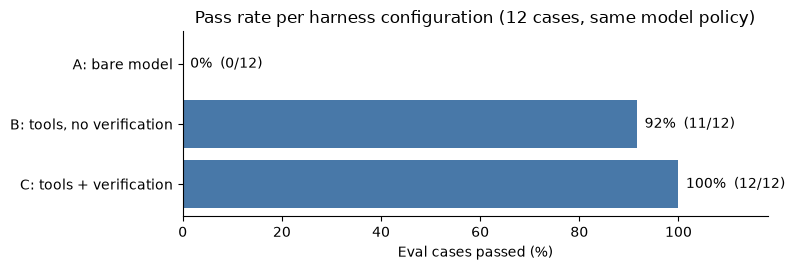

In [16]:
import matplotlib.pyplot as plt

names = list(reports)
passed = [sum(r["passed"] for r in reports[n].rows) for n in names]
rates = [reports[n].pass_rate * 100 for n in names]

fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh(names, rates, color="#4878a8")
ax.invert_yaxis()                                   # configuration A at the top
ax.set_xlim(0, 118)
ax.set_xlabel("Eval cases passed (%)")
ax.set_title(f"Pass rate per harness configuration ({len(cases)} cases, same model policy)")
for bar, rate, n_ok in zip(bars, rates, passed):
    ax.text(rate + 1.5, bar.get_y() + bar.get_height() / 2, f"{rate:.0f}%  ({n_ok}/{len(cases)})", va="center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

How to read it: one bar per harness configuration, longer is better; the label is the share of the twelve cases that passed. The model is identical in all three rows, so every difference between bars is the harness.

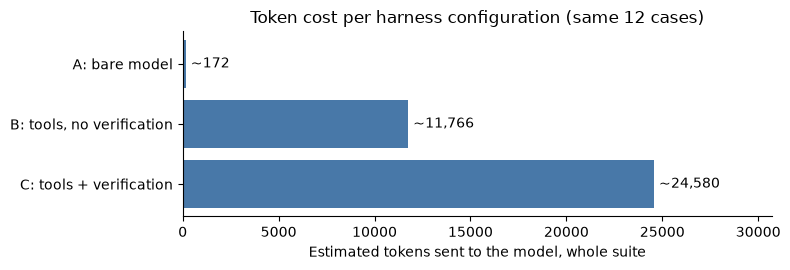

In [17]:
tokens = [reports[n].tokens for n in names]

fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh(names, tokens, color="#4878a8")
ax.invert_yaxis()
ax.set_xlim(0, max(tokens) * 1.25)
ax.set_xlabel("Estimated tokens sent to the model, whole suite")
ax.set_title("Token cost per harness configuration (same 12 cases)")
for bar, t in zip(bars, tokens):
    ax.text(t + max(tokens) * 0.01, bar.get_y() + bar.get_height() / 2, f"~{t:,}", va="center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

How to read it: one bar per configuration, shorter is cheaper; the label is the estimated number of tokens the whole suite sent to the model. Compare it with the chart above: the bars that pass more cases are also the bars that cost more.

### The one failure in B: the no-answer trap

Configuration B passed every factual case and failed exactly one: the trap. Look at what it answered.

In [18]:
trap = "no-answer"
for name in names[1:]:
    row = next(r for r in reports[name].rows if r["case"] == trap)
    print(f"{name} ({'pass' if row['passed'] else 'FAIL'}, {row['turns']} turns):")
    print("   ", row["answer"][:230])
    print()

B: tools, no verification (FAIL, 3 turns):
    Anthropic introduced Agent Skills on 16 October 2025 in the post "Equipping agents for the real world with Agent Skills" and published the format as an open standard on 18 December 2025; by 2026 more than forty platforms support i

C: tools + verification (pass, 5 turns):
    I could not verify an answer against the library. Anthropic's post "Effective context engineering for AI agents" (29 September 2025) describes three techniques for long tasks. (unverified)



B searched for the question's key words, got the best-scoring document the library had (the Agent Skills page, which merely mentions Anthropic), read it and confidently cited it as if it answered the question. Nothing in B's harness could notice that the document does not address the question. C ran `check_citation`, which compared the answer with the question and the document, reported a problem, tried the runner-up document, and finally said that it could not verify an answer. That sentence is the correct output. The trap is the most important case in the suite, because it is the one failure a user cannot detect by reading the answer: it looks exactly like a good one.

### The price of verification

In [19]:
b, c = reports["B: tools, no verification"], reports["C: tools + verification"]
ratio = c.tokens / b.tokens
print(f"B: {b.pass_rate:.1%} pass, ~{b.tokens:,} tokens, mean {b.summary()['mean_turns']} turns per case")
print(f"C: {c.pass_rate:.1%} pass, ~{c.tokens:,} tokens, mean {c.summary()['mean_turns']} turns per case")
print(f"Verification bought {sum(r['passed'] for r in c.rows) - sum(r['passed'] for r in b.rows)} extra case(s) "
      f"at {ratio:.1f}x the tokens ({c.tokens - b.tokens:,} more).")

B: 91.7% pass, ~11,766 tokens, mean 3.0 turns per case
C: 100.0% pass, ~24,580 tokens, mean 4.08 turns per case
Verification bought 1 extra case(s) at 2.1x the tokens (12,814 more).


Verification roughly doubled the bill for one extra passing case. Whether that is a good deal depends on the case: if the one failure is a customer being told an invented fact with a confident citation, it is cheap. The point of an eval suite is that this becomes a number you can discuss, instead of an opinion. Anthropic's advice to "invest in the agent-computer interface" and OpenAI's "corrections are cheap, waiting is expensive" both land here: the eval tells you where the correction is needed, and the trace in the next section tells you what it costs.

## 5. Observability: the trace, the summary and the bill

Concrete anchor: the dashboard and the flight recorder. A car without a fuel gauge still drives, but you find out about the empty tank by stopping. A **trace** is the record of every step an agent took: each model call with the size of the context it saw, each tool call with its arguments and result, each denial, compaction and validator note. Without it you cannot say why a run cost what it cost or where it went wrong; with it, every number in this notebook becomes explainable.

Our `Trace` has three views. `show()` prints the step log you have been reading all along. `summary()` returns the totals as a dictionary (model calls, tool calls, denials, estimated tokens). `cost(usd_per_million_tokens)` turns the tokens into money for a model at a given price. The token counts are estimates, about four characters per token, which is close enough to see the shape of a bill; a real provider reports exact counts in every response and a real harness records those.

In [20]:
result.trace.show()
summary = result.trace.summary()
summary.pop("seconds")          # wall-clock time varies by machine; everything else is deterministic
print()
print("summary:", summary)
print(f"if this were a paid model at 3 dollars per million tokens, this run would cost about ${result.trace.cost(3.0):.4f}")

trace of 'researcher': 4 model calls, 3 tool calls, ~1904 tokens
   1  model    research           search_docs({'query': 'anthropic open-source model contex...
   1  tool     search_docs        (query='anthropic open-source model context prot', k='3')...
   2  model    research           read_doc({'doc_id': 'model-context-protocol'})
   2  tool     read_doc           (doc_id='model-context-protocol') -> id: model-context-pr...
   3  model    research           check_citation({'answer': 'Anthropic open-sourced the Mod...
   3  tool     check_citation     (answer='Anthropic open-sourced the Model Context', quest...
   4  model    research           Anthropic open-sourced the Model Context Protocol on 25 N...
   4  final    researcher         Anthropic open-sourced the Model Context Protocol on 25 N...

summary: {'agent': 'researcher', 'model_calls': 4, 'tool_calls': 3, 'denied': 0, 'estimated_tokens': 1904}
if this were a paid model at 3 dollars per million tokens, this run would cost ab

Less than a cent for one cited answer. Now the whole eval suite, per configuration: this is the number you would pay every time the suite runs in continuous integration.

In [21]:
PRICE = 3.0     # dollars per million tokens, a mid-range price in 2026
bill = pd.DataFrame({
    "tokens": [reports[n].tokens for n in names],
    "cost_usd_at_3_per_M": [round(reports[n].tokens / 1_000_000 * PRICE, 4) for n in names],
    "pass_rate_%": [round(reports[n].pass_rate * 100, 1) for n in names],
}, index=names)
display(bill)
print(f"Running the full suite on configuration C costs about ${bill.loc['C: tools + verification', 'cost_usd_at_3_per_M']:.2f} per run.")

,tokens,cost_usd_at_3_per_M,pass_rate_%
A: bare model,172,0.0005,0.0
"B: tools, no verification",11766,0.0353,91.7
C: tools + verification,24580,0.0737,100.0


Running the full suite on configuration C costs about $0.07 per run.


### Evals as CI, and the repository as system of record

Anthropic's eval post makes the operational point: evals run like tests in continuous integration, so a change to a prompt, a tool or a model shows its effect **before** users see it (Anthropic, "Demystifying evals for AI agents", Jan 2026). At a few cents per run there is no budget argument against it. Yet Marmelab's 2026 survey found that **60 percent of harnesses ship without tests or evals**. The field builds the engine and skips the dashboard.

OpenAI's harness team went further and turned the whole practice into an engineering discipline (Lopopolo, "Harness engineering: leveraging Codex in an agent-first world", 11 Feb 2026). In a five-month experiment they shipped about one million lines of production code with zero lines written by hand. Three habits made it work:

- **The repository is the system of record.** Design documents, decision records, execution plans and even "taste invariants" (the team's rules about what good code looks like) live as versioned markdown next to the code, where the agent can read them on every task.
- **Constraints are enforced mechanically.** Custom linters and structural tests in CI check the rules; an instruction the agent might ignore becomes a test it cannot.
- **Corrections are cheap, waiting is expensive.** A wrong attempt that fails a test costs a minute; a human reviewing every step costs hours. So the harness is built to let the agent try and to catch mistakes automatically.

In their words, harness engineering is deterministic scaffolding around probabilistic model steps. The eval suite you just built is the smallest possible version of that scaffolding.

## 6. Optional: the same harness on a real model

Everything above used the `ScriptedModel`. The harness never looked inside it; it only called `complete(system, messages, tools)` and got a message back. `harness/providers.py` offers the same interface for Claude (`AnthropicModel`, default `claude-opus-5`) and for GPT (`OpenAIModel`), so the whole notebook works with a real engine by changing one line.

`connect()` asks for your API key with `getpass`, which hides what you type and keeps the key in memory only. It is never written to the notebook, so it can never end up in the repository. Set `RUN_REAL = True` and run the cell if you have a key and want to see a real model drive the same loop. Its trace will not match the scripted numbers exactly, because a real model is not deterministic; that is the whole reason the course teaches with a scripted one.

In [22]:
RUN_REAL = False  # set True and run to try a real model

if RUN_REAL:
    from harness.providers import connect
    model = connect("anthropic")            # or connect("openai"); the key is asked for with getpass
    real = Agent(model, tools=RESEARCH_TOOLS,
                 system="Answer from the library and cite the document you used.", name="real")
    real_result = real.run(Q1)
    print(real_result.answer)
    real_result.trace.show()
    print("estimated tokens:", real_result.tokens, "| at 3 dollars per million: $", real_result.trace.cost(3.0))
else:
    print("RUN_REAL is False: skipped. Everything above ran without a key.")

RUN_REAL is False: skipped. Everything above ran without a key.


## 7. Key takeaways

- The agent loop is **gather context, take action, verify work, repeat**, with three stop conditions: done, max turns and budget. `max_turns` is the seatbelt; a harness without one is not finished.
- A **guardrail** is a check that runs outside the model. `before_tool` hooks enforce rules, `validate_answer` hooks enforce standards, and `permission` gates tools by risk level. Validators state the standard; tools make it reachable.
- The **approval paradox**: 93 percent of permission prompts are approved, so a guardrail that asks is barely a guardrail. Make the common protections mechanical and save the human prompt for the rare decision.
- A **workflow** is a path you wrote in code with model steps inside; an **agent** is the model choosing the path. Five patterns cover most needs; start with the simplest one that works, and let the model drive only when the steps cannot be predicted.
- An **eval** is a task, a grader and an outcome. Same model, three harnesses: the bare model passed nothing, tools without verification passed everything except the trap, verification passed everything at about twice the tokens. Include a trap case; it is the failure users cannot see.
- A **trace** makes every run explainable and every token a cost you can compute. Run the evals in CI, and treat the repository as the system of record.

## 8. Practice exercises

Try these before looking at the solutions.

**Exercise 1 - Add an eval case.** The library's `harness-effect` document says that on Terminal-Bench 2, changing only the harness raised pass@1 from 69.7 to 77.0 percent. Write an `EvalCase` that asks for that number and requires the right citation, run it through configurations B and C, and check that both pass. Then invent a second trap question and see which configuration survives it.

**Exercise 2 - A hook that denies write tools.** `write_note` in `harness.demo_tools` has `risk="write"`. Write a `before_tool` hook that denies every tool whose risk is `write` with a clear reason, and prove it works with a small policy that tries to call `write_note`. Check that no `outputs/notes.md` file appears.

**Exercise 3 - Change `max_rounds`.** Run `evaluate_optimize` with the bare generator and the judge for `max_rounds` of 1, 2 and 4. Count the rounds and the model calls each time (`generator.model.calls_made`). What do the numbers tell you about adding rounds to a generator that cannot look things up?

## 9. Solutions

### Solution 1 - Add an eval case

The grader asks for the number "77.0" and the `harness-effect` citation. Configuration B reads the right document and passes; C passes too, one turn later, because it also verifies. The second trap, a question about revenue, is not in the library: B cites whatever scored highest, C says it could not verify.

The third case is a lesson about verification itself. Ask for the revenue "in 2025" and even C is fooled: the checker sees a document that mentions Anthropic and the year 2025 and lets the answer through. A verifier is only as good as its checks, which is exactly why you keep trap cases in the suite: they tell you where the checker needs to get stricter.

In [23]:
new_cases = [
    EvalCase("terminal-bench", "How much did pass@1 rise on Terminal-Bench 2 by changing only the harness?",
             all_of(contains("77.0"), cites("harness-effect"))),
    EvalCase("no-answer-2", "What is Anthropic's annual revenue?", contains("could not verify")),
    EvalCase("no-answer-3", "What was Anthropic's revenue in 2025?", contains("could not verify")),
]
extra = compare({k: v for k, v in configs.items() if not k.startswith("A")}, new_cases)
for report in extra.values():
    report.show()
    print()

B: tools, no verification: 33% pass (1/3), ~2884 tokens
  pass  terminal-bench               turns=3  tools=2  'On Terminal-Bench 2, changing only the harness raised pass@1'
  FAIL  no-answer-2                  turns=3  tools=2  'Anthropic introduced Agent Skills on 16 October 2025 in the '
  FAIL  no-answer-3                  turns=3  tools=2  'Anthropic introduced Agent Skills on 16 October 2025 in the '

C: tools + verification: 67% pass (2/3), ~6912 tokens
  pass  terminal-bench               turns=4  tools=3  'On Terminal-Bench 2, changing only the harness raised pass@1'
  pass  no-answer-2                  turns=5  tools=4  "I could not verify an answer against the library. Anthropic'"
  FAIL  no-answer-3                  turns=4  tools=3  'Anthropic introduced Agent Skills on 16 October 2025 in the '



### Solution 2 - A hook that denies write tools

The hook receives the request and the `Tool` object (or `None` if the tool does not exist), so it can look at `tool.risk` directly. The model's attempt shows up in the trace as a `denied` event and the notes file is never created.

In [24]:
import pathlib
from harness.demo_tools import write_note, read_notes

def no_writes(request, tool):
    if tool is not None and tool.risk == "write":
        return f"'{request.name}' is a write tool and writing is switched off in this session"
    return None

def note_taker(view):
    if view.has_tool("write_note") and not view.called("write_note"):
        return call("write_note", text="MCP was open-sourced on 25 November 2024 [source: model-context-protocol]")
    return say("The note step said: " + (view.last_result("write_note") or ""))

read_only = Agent(ScriptedModel(note_taker, name="note-taker"), tools=[write_note, read_notes],
                  hooks=Hooks(before_tool=[no_writes]), name="read-only")
ro = read_only.run("Remember the MCP date for later")
print(ro.answer)
print("notes file exists:", pathlib.Path("outputs/notes.md").exists())
ro.trace.show()

The note step said: Denied: 'write_note' is a write tool and writing is switched off in this session
notes file exists: False
trace of 'read-only': 2 model calls, 0 tool calls, ~146 tokens
   1  model    note-taker         write_note({'text': 'MCP was open-sourced on 25 November ...
   1  denied   write_note         'write_note' is a write tool and writing is switched off ...
   2  model    note-taker         The note step said: Denied: 'write_note' is a write tool ...
   2  final    read-only          The note step said: Denied: 'write_note' is a write tool ...


### Solution 3 - Change `max_rounds`

Every extra round costs two model calls (one draft, one judgement) and changes nothing: the verdict is the same each time, because the bare generator has no way to act on the feedback. More rounds only help when the generator can do something different with the critique, which in practice means giving it tools or a better prompt, not a longer loop.

In [25]:
for rounds in (1, 2, 4):
    generator = Agent(ScriptedModel(bare_policy, name="bare"), name="bare-generator")
    outcome = evaluate_optimize(generator, judge, Q1, max_rounds=rounds)
    verdicts = {h["verdict"]["reason"] for h in outcome["history"]}
    print(f"max_rounds={rounds}: passed={outcome['passed']}, rounds used={outcome['rounds']}, "
          f"generator model calls={generator.model.calls_made}, distinct verdicts={verdicts}")

max_rounds=1: passed=False, rounds used=1, generator model calls=1, distinct verdicts={'missing a [source: id] citation'}
max_rounds=2: passed=False, rounds used=2, generator model calls=2, distinct verdicts={'missing a [source: id] citation'}
max_rounds=4: passed=False, rounds used=4, generator model calls=4, distinct verdicts={'missing a [source: id] citation'}
